# Medical MNIST — Denoising Autoencoder & VAE Experiment

This notebook trains per-region **Denoising Autoencoders (DAE)** and **Denoising Variational Autoencoders (DVAE)** on the [Medical MNIST](https://www.kaggle.com/datasets/andrewmvd/medical-mnist) dataset, then compares reconstruction quality, latent-space structure, noise robustness, and generative capability.

**Sections:**
1. Imports & Configuration
2. Data Loading (`tf.data` pipelines)
3. Model Definitions (AE, DAE, VAE, DVAE)
4. Training
5. Visual Comparison & Analysis
6. Sample Generation

# Imports

In [58]:
"""
Imports — All external dependencies required by this notebook.

Libraries:
    - tensorflow / keras : Model building, training, and data pipelines (tf.data).
    - numpy              : Array operations for post-processing.
    - matplotlib         : All visualisation and plotting.
    - sklearn (PCA)      : Dimensionality reduction for latent-space plots.
"""

import os
import logging

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA

# Suppress noisy TensorFlow C++ logs (CUDA / XLA registration warnings)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Configuration

In [59]:
"""Hyperparameters and dataset paths — edit these to tune the experiment."""

# ─── Image & Training Hyperparameters ────────────────────────────────────────
IMG_SIZE    = 64       # Resize all images to IMG_SIZE × IMG_SIZE pixels
BATCH_SIZE  = 32       # Mini-batch size for training
LATENT_DIM  = 32       # Dimensionality of the latent (bottleneck) vector
EPOCHS      = 30       # Number of training epochs per region
NOISE_LEVEL = 0.2      # Std-dev of Gaussian noise for the denoising objective

# ─── Dataset ─────────────────────────────────────────────────────────────────
# Kaggle dataset root (matches the 'andrewmvd/medical-mnist' dataset slug)
DATASET_PATH = '/kaggle/input/datasets/andrewmvd/medical-mnist'

# ─── Derived Constants ───────────────────────────────────────────────────────
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 1)  # Single-channel (grayscale) image shape

# Auto-detect class names from the dataset directory
classes = sorted(os.listdir(DATASET_PATH))
print(f"Detected regions: {classes}")

Detected regions: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


# Data Loading (`tf.data` Pipelines)

All data loading uses `tf.data.Dataset` for efficient, parallelised I/O
with automatic prefetching.

In [60]:
def load_image(file_path):
    """Read, decode, resize, and normalise a single image to [0, 1].

    Args:
        file_path: Scalar string tensor — path to the image file.

    Returns:
        A float32 tensor of shape (IMG_SIZE, IMG_SIZE, 1) with values in [0, 1].
    """
    raw = tf.io.read_file(file_path)
    # decode_image supports JPEG / PNG / BMP / GIF; channels=1 forces grayscale
    img = tf.io.decode_image(raw, channels=1, expand_animations=False)
    img.set_shape([None, None, 1])  # Static shape hint required after decode_image
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # Normalise pixel values to [0, 1]
    return img

In [61]:
def create_train_dataset(dataset_path, region, batch_size=BATCH_SIZE):
    """Build a tf.data.Dataset of (image, image) pairs for a single region.

    The target is identical to the input so that the autoencoder learns
    reconstruction.  Noise injection happens inside the model's train_step,
    not in the data pipeline.

    Args:
        dataset_path: Root directory containing one sub-folder per class.
        region:       Name of the class sub-folder (e.g. 'Hand', 'CXR').
        batch_size:   Number of samples per mini-batch.

    Returns:
        A shuffled, batched, and prefetched tf.data.Dataset.
    """
    pattern = os.path.join(dataset_path, region, "*")
    ds = tf.data.Dataset.list_files(pattern, shuffle=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x: (x, x))  # input == target for autoencoders
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [62]:
def create_labeled_dataset(dataset_path, classes, batch_size=500, shuffle=True):
    """Build a tf.data.Dataset of (image, int_label) pairs across all classes.

    Used for colour-coded latent-space visualisation, where each class
    receives a unique integer label.

    Args:
        dataset_path: Root directory containing one sub-folder per class.
        classes:      Sorted list of class names (order determines label index).
        batch_size:   Number of samples per mini-batch.
        shuffle:      Whether to shuffle the dataset.

    Returns:
        A batched and prefetched tf.data.Dataset of (image, label) pairs.
    """
    all_files  = []
    all_labels = []
    for i, cls in enumerate(classes):
        pattern = os.path.join(dataset_path, cls, "*")
        files = sorted(tf.io.gfile.glob(pattern))
        all_files.extend(files)
        all_labels.extend([i] * len(files))

    ds = tf.data.Dataset.from_tensor_slices((all_files, all_labels))
    if shuffle:
        ds = ds.shuffle(len(all_files))
    ds = ds.map(
        lambda f, l: (load_image(f), l),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [63]:
def create_evaluation_dataset(dataset_path, region, batch_size=1, shuffle=True):
    """Build a single-region image dataset (no labels) for evaluation demos.

    Args:
        dataset_path: Root directory containing one sub-folder per class.
        region:       Name of the class sub-folder.
        batch_size:   Number of samples per mini-batch.
        shuffle:      Whether to shuffle the images.

    Returns:
        A batched and prefetched tf.data.Dataset of image tensors.
    """
    pattern = os.path.join(dataset_path, region, "*")
    ds = tf.data.Dataset.list_files(pattern, shuffle=shuffle)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Utility Functions

In [64]:
def add_noise(images, noise_factor=0.2):
    """Add Gaussian noise to a batch of images and clip to [0, 1].

    Args:
        images:       Tensor of shape (batch, H, W, C) with values in [0, 1].
        noise_factor: Standard deviation of the Gaussian noise.

    Returns:
        Noisy images clipped to the valid pixel range [0, 1].
    """
    noise = tf.random.normal(
        shape=tf.shape(images), mean=0.0, stddev=noise_factor, dtype=tf.float32
    )
    noisy_images = images + noise
    return tf.clip_by_value(noisy_images, clip_value_min=0.0, clip_value_max=1.0)

# Models

## Autoencoder (AE)

### Regular Autoencoder

In [65]:
def build_autoencoder(img_shape, latent_dim):
    """Build and return a compiled convolutional autoencoder.

    Architecture:
        Encoder: Conv2D(32) → Conv2D(64) → Flatten → Dense(latent_dim)
        Decoder: Dense(16×16×64) → Reshape → ConvT(64) → ConvT(32) → ConvT(1, sigmoid)

    Args:
        img_shape:  Tuple (H, W, C) defining the input image dimensions.
        latent_dim: Size of the bottleneck latent vector.

    Returns:
        A compiled Keras Model (end-to-end autoencoder, MSE loss).
    """
    # Encoder
    encoder_inputs = keras.Input(shape=img_shape)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    latent_space = layers.Dense(latent_dim)(x)
    encoder = keras.Model(encoder_inputs, latent_space)

    # Decoder
    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs)

    # End-to-end model: input → encoder → decoder → output
    autoencoder = keras.Model(encoder_inputs, decoder(encoder(encoder_inputs)))
    autoencoder.compile(optimizer="adam", loss="mse")

    return autoencoder

### Denoising Autoencoder (used for training)

In [66]:
def build_autoencoder_components(img_shape, latent_dim):
    """Build encoder and decoder as separate Keras models for the Denoising AE.

    Identical architecture to build_autoencoder, but returns the encoder and
    decoder independently so they can be wrapped in the DenoisingAE class.

    Args:
        img_shape:  Tuple (H, W, C) for input dimensions.
        latent_dim: Size of the bottleneck latent vector.

    Returns:
        Tuple of (encoder, decoder) Keras Models.
    """
    # Encoder: progressively downsample spatial dims, flatten to latent vector
    encoder_inputs = keras.Input(shape=img_shape)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    latent_space = layers.Dense(latent_dim, name="latent_vector")(x)
    encoder = keras.Model(encoder_inputs, latent_space, name="ae_encoder")

    # Decoder: project latent vector back to spatial feature map, upsample
    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="ae_decoder")

    return encoder, decoder

In [67]:
class DenoisingAE(keras.Model):
    """Custom Keras model that injects Gaussian noise during training.

    During training, clean images are corrupted with additive Gaussian noise
    and the model learns to reconstruct the original (clean) images.  At
    inference time, no noise is injected — the model acts as a standard AE.

    Attributes:
        encoder:      Keras Model mapping images → latent vectors.
        decoder:      Keras Model mapping latent vectors → reconstructed images.
        noise_factor: Std-dev of the Gaussian noise added during training.
    """

    def __init__(self, encoder, decoder, noise_factor=0.2, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.noise_factor = noise_factor
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def call(self, inputs, training=False):
        """Forward pass: encode then decode (no noise at inference)."""
        latent = self.encoder(inputs)
        return self.decoder(latent)

    def train_step(self, data):
        """Single training step with noise injection.

        1. Extract clean images from the (input, target) tuple.
        2. Add Gaussian noise to create corrupted inputs.
        3. Forward-pass the noisy images, compute MSE against clean targets.
        4. Update weights via backpropagation.
        """
        if isinstance(data, tuple):
            clean_images = data[0]

        # Inject Gaussian noise and clip to valid pixel range
        noise = tf.random.normal(
            shape=tf.shape(clean_images), mean=0.0, stddev=self.noise_factor
        )
        noisy_images = tf.clip_by_value(clean_images + noise, 0.0, 1.0)

        with tf.GradientTape() as tape:
            # Reconstruct from noisy input
            reconstruction = self(noisy_images, training=True)
            # MSE loss between clean original and reconstruction
            loss = tf.reduce_mean(tf.square(clean_images - reconstruction))

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

## Variational Autoencoder (VAE)

### Sampling Layer (Reparameterisation Trick)

In [68]:
class Sampling(layers.Layer):
    """Reparameterisation-trick sampling layer for a VAE.

    Given z_mean and z_log_var from the encoder, samples a latent vector z:
        z = z_mean + exp(0.5 * z_log_var) * ε,   ε ~ N(0, I)

    This allows gradients to flow through the stochastic sampling step.
    """

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # Sample ε from a standard normal distribution
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Reparameterisation: shift by mean, scale by learned std-dev
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### Regular VAE

In [69]:
class VAE(keras.Model):
    """Vanilla convolutional VAE with KL divergence + reconstruction loss.

    The ELBO objective is decomposed into two terms:
      - Reconstruction loss: binary cross-entropy between input and output.
      - KL divergence: regularises the latent distribution towards N(0, I).

    Attributes:
        encoder: Keras Model returning (z_mean, z_log_var, z).
        decoder: Keras Model mapping z → reconstructed image.
    """

    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # Track each loss component separately for logging
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        """Tells Keras to reset these trackers at the start of every epoch."""
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        """Single training step computing ELBO = reconstruction + KL."""
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction Loss (binary cross-entropy, summed over pixels)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )

            # KL Divergence: D_KL( q(z|x) || p(z) )  where p(z) = N(0, I)
            kl_loss = -0.5 * (
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metric trackers
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

### VAE Encoder & Decoder Components

In [70]:
def build_vae_components(img_shape, latent_dim):
    """Build encoder and decoder for a convolutional VAE.

    The encoder outputs three tensors: z_mean, z_log_var, and a sampled z.
    The decoder maps z back to the image space via transposed convolutions.

    Args:
        img_shape:  Tuple (H, W, C) for input dimensions.
        latent_dim: Size of the latent vector z.

    Returns:
        Tuple of (encoder, decoder) Keras Models.
    """
    # Encoder: same conv backbone, but outputs distribution parameters
    encoder_inputs = keras.Input(shape=img_shape)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    z_mean    = layers.Dense(latent_dim)(x)      # Mean of q(z|x)
    z_log_var = layers.Dense(latent_dim)(x)      # Log-variance of q(z|x)
    z = Sampling()([z_mean, z_log_var])           # Reparameterised sample
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z])

    # Decoder: identical architecture to the AE decoder
    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs)

    return encoder, decoder

### Denoising VAE (used for training)

In [71]:
class DenoisingVAE(keras.Model):
    """VAE that adds Gaussian noise to inputs during training (denoising objective).

    Combines the denoising objective (learn to remove noise) with the VAE's
    latent regularisation (KL divergence).  At inference, no noise is injected.

    Attributes:
        encoder:      Keras Model returning (z_mean, z_log_var, z).
        decoder:      Keras Model mapping z → reconstructed image.
        noise_factor: Std-dev of additive Gaussian noise during training.
    """

    def __init__(self, encoder, decoder, noise_factor=0.2, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.noise_factor = noise_factor
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs, training=False):
        """Forward pass: encode (sample z) then decode."""
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    @property
    def metrics(self):
        """Reset all trackers at the start of every epoch."""
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        """Training step: noise injection + ELBO loss (reconstruction + KL).

        1. Extract clean images, add Gaussian noise.
        2. Encode noisy images → (z_mean, z_log_var, z).
        3. Decode z → reconstruction.
        4. Compute reconstruction loss (BCE) + KL divergence against clean targets.
        """
        if isinstance(data, tuple):
            clean_images = data[0]

        # Inject noise and clip to valid pixel range
        noise = tf.random.normal(
            shape=tf.shape(clean_images), mean=0.0, stddev=self.noise_factor
        )
        noisy_images = tf.clip_by_value(clean_images + noise, 0.0, 1.0)

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(noisy_images)
            reconstruction = self.decoder(z)

            # Reconstruction loss: BCE summed over pixels, averaged over batch
            r_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        clean_images, reconstruction
                    ),
                    axis=(1, 2),
                )
            )
            # KL divergence: regularise q(z|x) towards N(0, I)
            k_loss = -0.5 * (
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )
            k_loss = tf.reduce_mean(tf.reduce_sum(k_loss, axis=1))
            total_loss = r_loss + k_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(k_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Training

## Denoising Autoencoder Training

In [72]:
ae_histories = {}
ae_models = {}

print("--- TRAINING DENOISING AUTOENCODERS ---")
for region in classes:
    print(f"Region: {region}")

    # Build a tf.data pipeline for the current region
    train_ds = create_train_dataset(DATASET_PATH, region, BATCH_SIZE)

    # Instantiate fresh encoder / decoder and wrap in DenoisingAE
    enc, dec = build_autoencoder_components(IMG_SHAPE, LATENT_DIM)
    dae = DenoisingAE(enc, dec, noise_factor=NOISE_LEVEL)
    dae.compile(optimizer='adam')

    history = dae.fit(train_ds, epochs=EPOCHS, verbose=1)
    ae_histories[region] = history.history
    ae_models[region] = dae

--- TRAINING DENOISING AUTOENCODERS ---
Region: AbdomenCT
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0085
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0038
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0029
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0025
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0023
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0021
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0020
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0019
Epoch 9/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0018
Epoch 10/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0018
Epoch 11/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0017
Epoch 12/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0017
Epoch 13/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0017
Epoch 14/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step 

## Denoising VAE Training

In [73]:
vae_models = {}
vae_histories = {}

print("--- STARTING DENOISING VAE TRAINING ---")
for region in classes:
    print(f"\nTraining DVAE for: {region}")

    # Build a tf.data pipeline for the current region
    train_ds = create_train_dataset(DATASET_PATH, region, BATCH_SIZE)

    # Instantiate fresh VAE components and wrap in DenoisingVAE
    enc, dec = build_vae_components(IMG_SHAPE, LATENT_DIM)
    dvae = DenoisingVAE(enc, dec, noise_factor=NOISE_LEVEL)
    dvae.compile(optimizer=keras.optimizers.Adam())

    history = dvae.fit(train_ds, epochs=EPOCHS)
    vae_histories[region] = history.history
    vae_models[region] = (enc, dec)

--- STARTING DENOISING VAE TRAINING ---

Training DVAE for: AbdomenCT
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - kl_loss: 0.1936 - loss: 2799.1426 - reconstruction_loss: 2798.9495
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 1.5077 - loss: 2787.3979 - reconstruction_loss: 2785.8904
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 4.5386 - loss: 2778.6819 - reconstruction_loss: 2774.1431
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 7.1732 - loss: 2771.1331 - reconstruction_loss: 2763.9602
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 7.7891 - loss: 2768.8091 - reconstruction_loss: 2761.0198
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 8.2144 - loss: 2766.8740 - reconstruction_loss: 2758.6594
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - kl_loss: 8.5847 - loss: 2765.9155 - reconstruction_loss: 2757.3313
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 8.9801 - lo

# Visual Comparison

## Visualisation Functions

### Latent Space Visualisation

In [74]:
def visualize_latent_space(region_name, model_type='ae'):
    """Project latent encodings into 2D via PCA and scatter-plot by class.

    Encodes a batch of 500 images (from all classes) using the model
    trained on *region_name*, reduces to 2 principal components, and
    produces a colour-coded scatter plot.

    Args:
        region_name: Which region's model to use for encoding.
        model_type:  'ae' to use the AE encoder, 'vae' for the VAE encoder.
    """
    # 1. Prepare data — load 500 labelled images from all classes
    labeled_ds = create_labeled_dataset(DATASET_PATH, classes, batch_size=500)
    images, labels = next(iter(labeled_ds))
    images = images.numpy()
    labels = labels.numpy()

    # 2. Extract Latent Vectors using the appropriate encoder
    if model_type == 'ae':
        dae_instance = ae_models[region_name]
        # AE encoder outputs a single latent vector
        latent_vectors = dae_instance.encoder.predict(images, verbose=0)
    else:
        v_enc, _ = vae_models[region_name]
        # VAE encoder outputs [z_mean, z_log_var, z]; use z_mean for viz
        latent_vectors, _, _ = v_enc.predict(images, verbose=0)

    # 3. Reduce Dimensions to 2D using PCA
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)

    # 4. Plotting
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        latent_2d[:, 0], latent_2d[:, 1],
        c=labels, cmap='viridis', alpha=0.6,
    )

    # Add a legend mapping colour to class name
    cbar = plt.colorbar(scatter, ticks=range(len(classes)))
    cbar.ax.set_yticklabels(classes)

    plt.title(f"2D Latent Space ({model_type.upper()}) trained on {region_name}")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

### Loss / KL Divergence

In [75]:
def plot_vae_losses(histories):
    """Plot total, reconstruction, and KL loss per region on a log scale.

    Args:
        histories: Dict mapping region name → training metrics dict
                   (must contain 'loss', 'reconstruction_loss', 'kl_loss').
    """
    num_regions = len(histories)
    fig, axs = plt.subplots(num_regions, 1, figsize=(10, 5 * num_regions))
    plt.subplots_adjust(hspace=0.4)

    for i, (region, metrics) in enumerate(histories.items()):
        ax = axs[i] if num_regions > 1 else axs

        epochs = range(1, len(metrics['loss']) + 1)

        # Plot the three loss components
        ax.plot(epochs, metrics['loss'], 'k-', label='Total Loss', linewidth=2)
        ax.plot(epochs, metrics['reconstruction_loss'], 'r--', label='Reconstruction Loss')
        ax.plot(epochs, metrics['kl_loss'], 'b:', label='KL Divergence')

        ax.set_title(f"VAE Loss Breakdown: {region}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Loss Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Log scale helps visualise KL divergence alongside reconstruction loss
        ax.set_yscale('log')

    plt.show()

### Noise Robustness

In [76]:
def plot_denoising_results(region_name, noise_level=0.3):
    """Show Original → Noisy → AE denoised → VAE denoised side-by-side.

    Args:
        region_name: Which region to grab a test sample from.
        noise_level: Std-dev of Gaussian noise to apply.
    """
    # Grab a single clean image using tf.data
    eval_ds = create_evaluation_dataset(DATASET_PATH, region_name, batch_size=1)
    clean_img = next(iter(eval_ds))  # shape (1, H, W, 1)

    # Manually add noise
    noisy_img = add_noise(clean_img, noise_factor=noise_level)

    # Denoise via AE
    ae_denoised = ae_models[region_name](noisy_img, training=False)

    # Denoise via VAE
    v_enc, v_dec = vae_models[region_name]
    _, _, z = v_enc(noisy_img, training=False)
    vae_denoised = v_dec(z, training=False)

    # Plotting
    imgs   = [clean_img[0], noisy_img[0], ae_denoised[0], vae_denoised[0]]
    titles = ["Original", f"Noisy (\u03c3={noise_level})", "AE Denoised", "VAE Denoised"]

    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(imgs[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

## Plots

### Reconstruction Comparison

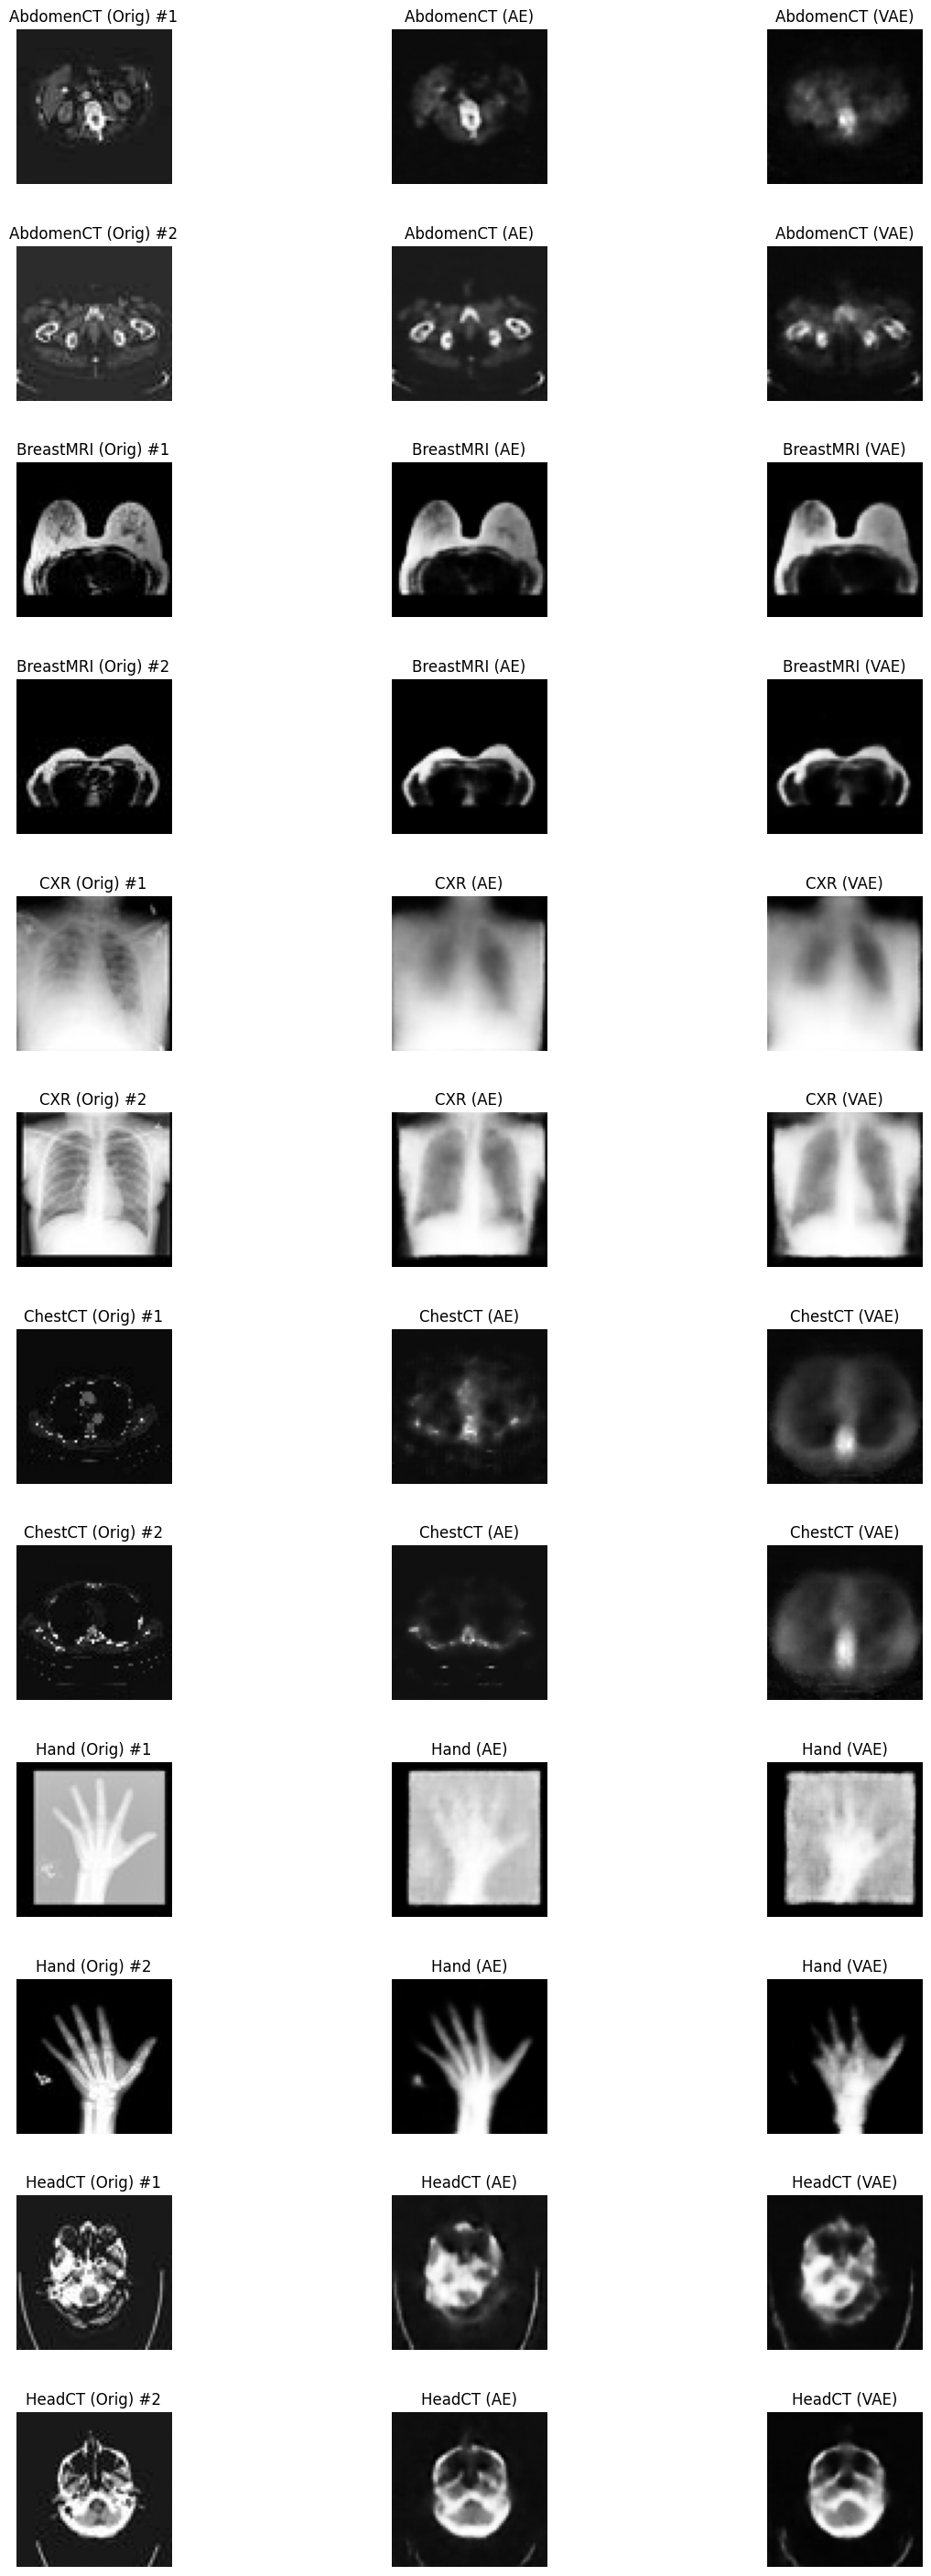

In [77]:
# Original vs AE vs VAE reconstruction — 2 samples per class, 3 columns
num_classes = len(classes)
fig, axs = plt.subplots(num_classes * 2, 3, figsize=(15, 3 * num_classes * 2))
plt.subplots_adjust(hspace=0.4)

for i, region in enumerate(classes):
    # Grab 2 random samples using tf.data
    eval_ds = create_evaluation_dataset(DATASET_PATH, region, batch_size=2)
    batch_imgs = next(iter(eval_ds))  # shape (2, IMG_SIZE, IMG_SIZE, 1)

    # Retrieve trained models
    ae_model = ae_models[region]
    v_enc, v_dec = vae_models[region]

    for j in range(2):  # Loop through the 2 samples
        img = batch_imgs[j:j+1]  # Keep batch dimension → shape (1, 64, 64, 1)
        row_idx = i * 2 + j

        # --- Predictions ---
        # AE reconstruction
        ae_rec = ae_model(img, training=False)

        # VAE reconstruction (extract z from encoder, then decode)
        _, _, z = v_enc.predict(img, verbose=0)
        vae_rec = v_dec.predict(z, verbose=0)

        # --- Plotting ---
        # Column 0: Original
        axs[row_idx, 0].imshow(img[0, :, :, 0], cmap='gray')
        axs[row_idx, 0].set_title(f"{region} (Orig) #{j+1}")
        axs[row_idx, 0].axis('off')

        # Column 1: AE Reconstruction
        axs[row_idx, 1].imshow(ae_rec[0, :, :, 0], cmap='gray')
        axs[row_idx, 1].set_title(f"{region} (AE)")
        axs[row_idx, 1].axis('off')

        # Column 2: VAE Reconstruction
        axs[row_idx, 2].imshow(vae_rec[0, :, :, 0], cmap='gray')
        axs[row_idx, 2].set_title(f"{region} (VAE)")
        axs[row_idx, 2].axis('off')

plt.show()

### Latent Space

In [78]:
region = 'Hand'

#### AE

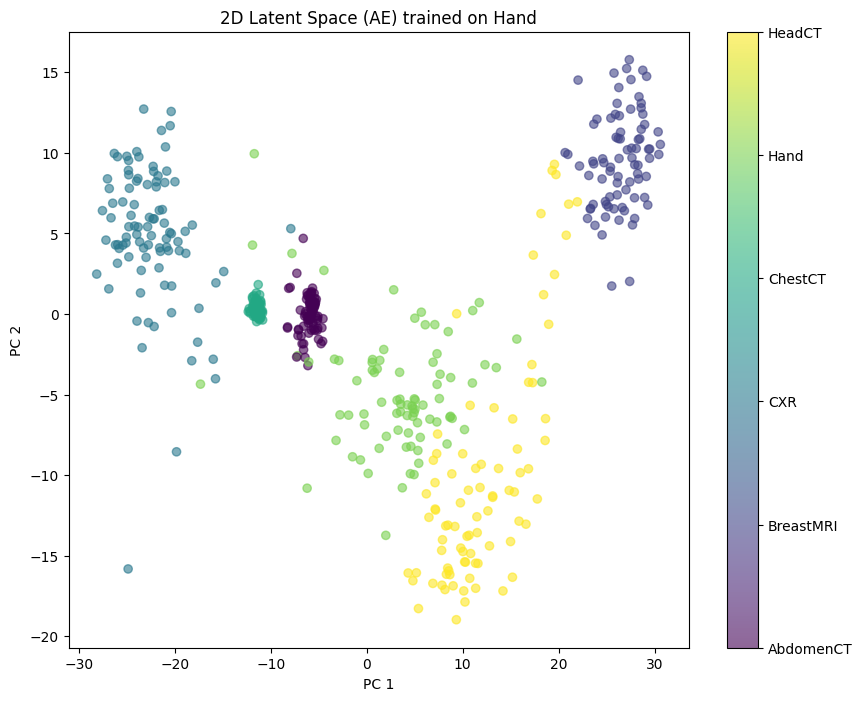

In [79]:
visualize_latent_space(region, model_type='ae')

#### VAE

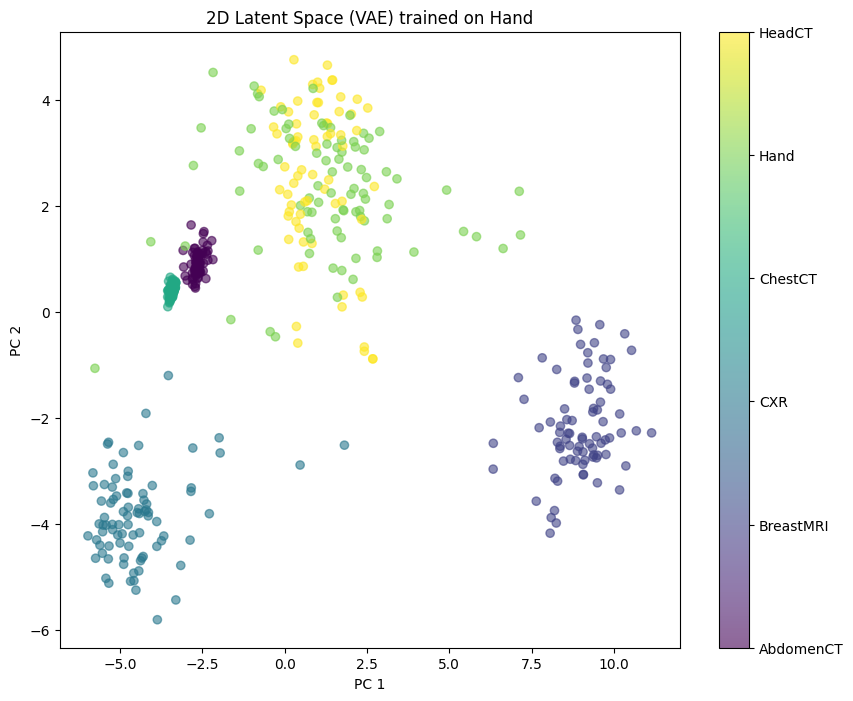

In [80]:
visualize_latent_space(region, model_type='vae')

### Loss / KL Divergence

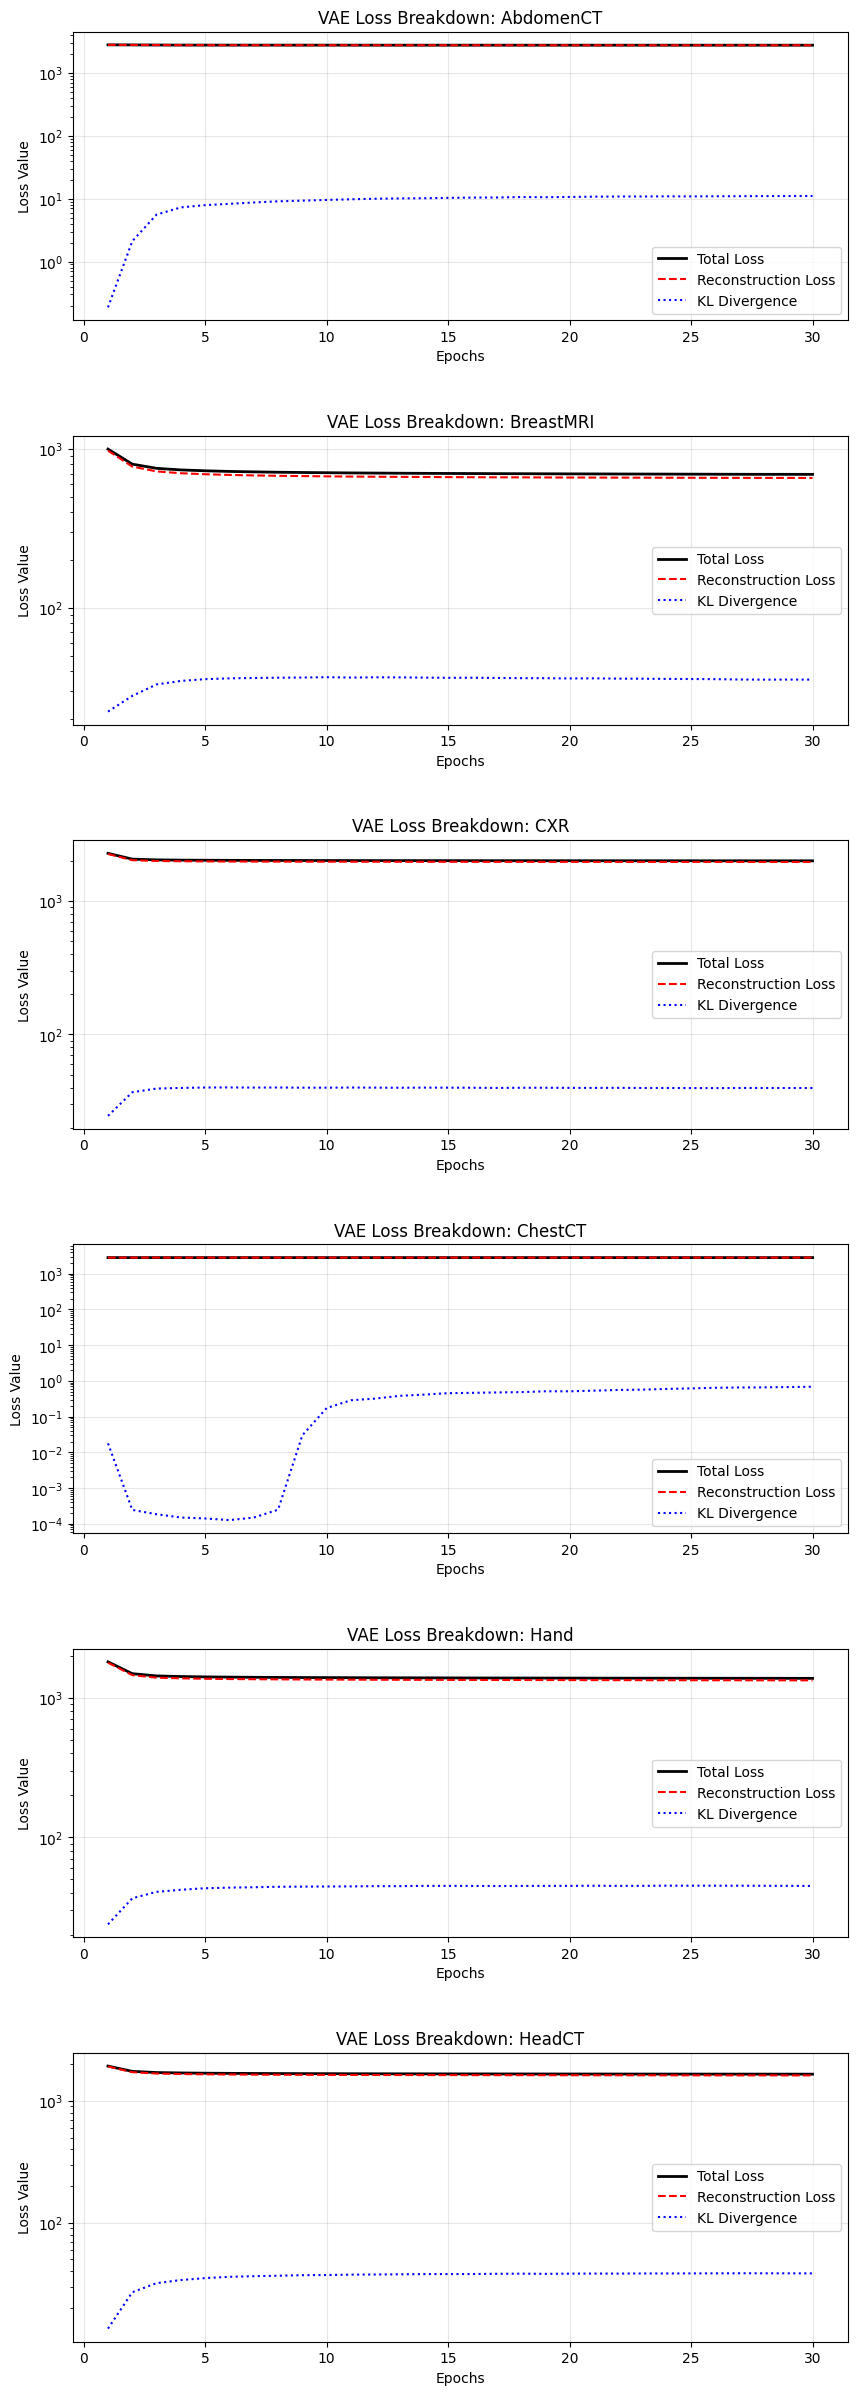

In [81]:
plot_vae_losses(vae_histories)

### Noise Robustness

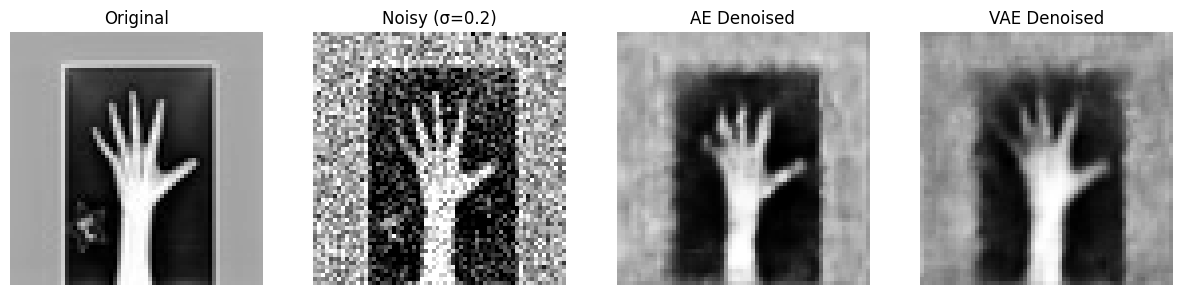

In [82]:
plot_denoising_results(region, NOISE_LEVEL)

# Sample Generation

--- GENERATING SYNTHETIC SAMPLES FROM LATENT SPACE ---


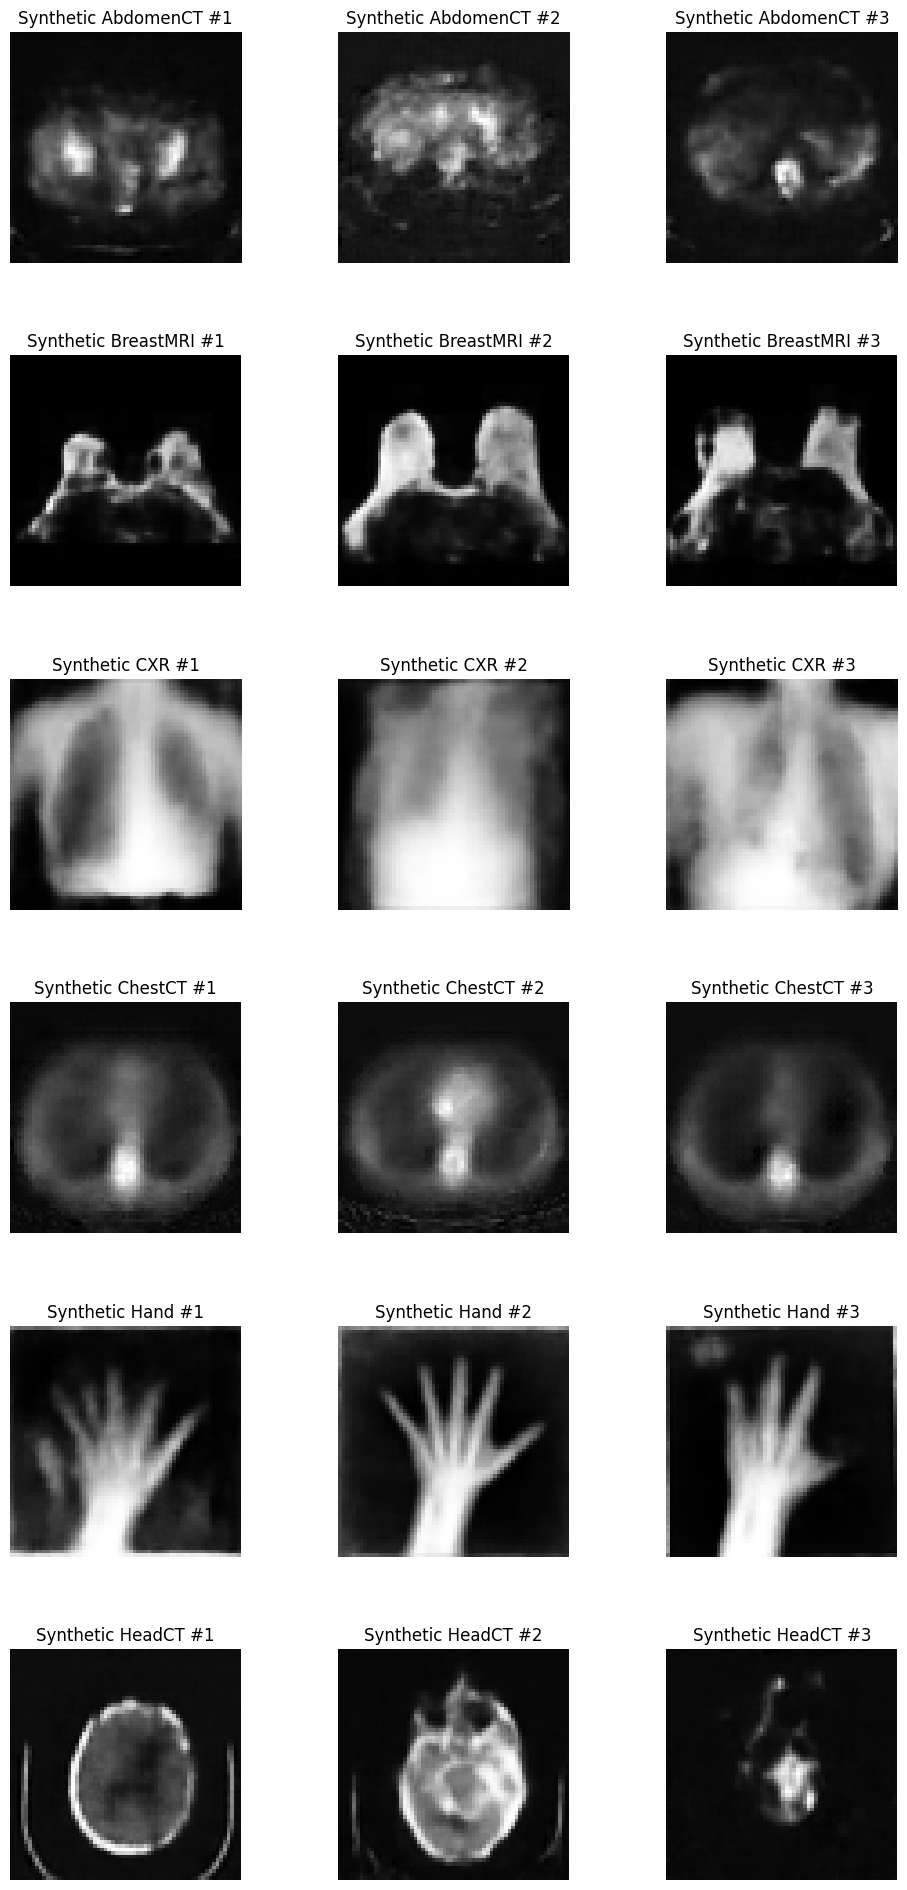

In [83]:
# Generate synthetic images by sampling from each VAE's learned latent space.
# Because the VAE regularises its latent space towards N(0, I), decoding
# random standard-normal vectors produces plausible novel images.
num_samples = 3

fig, axs = plt.subplots(
    len(classes), num_samples,
    figsize=(num_samples * 4, len(classes) * 4),
)
plt.subplots_adjust(hspace=0.4)

print("--- GENERATING SYNTHETIC SAMPLES FROM LATENT SPACE ---")

for i, region in enumerate(classes):
    # Retrieve the decoder for this specific region
    _, v_dec = vae_models[region]

    # 1. Sample from Standard Normal Distribution N(0, I)
    #    The VAE latent space is regularised to match this prior
    random_latent_vectors = tf.random.normal(shape=(num_samples, LATENT_DIM))

    # 2. Decode the random vectors into synthetic images
    synthetic_imgs = v_dec(random_latent_vectors, training=False).numpy()

    for j in range(num_samples):
        ax = axs[i, j] if len(classes) > 1 else axs[j]

        ax.imshow(synthetic_imgs[j, :, :, 0], cmap='gray')
        ax.set_title(f"Synthetic {region} #{j+1}")
        ax.axis('off')

plt.show()